# Run Parcels — eager full-load + native v3 JIT, 1M particles

This is the **native parcels v3** comparison point for the `02*` series: a
plain, idiomatic parcels v3 run straight out of the getting-started tutorial —
build a `FieldSet`, make a `ParticleSet` of `parcels.JITParticle`, execute
`parcels.AdvectionRK4`, write a `ParticleFile`, read it back, and plot. No
hand-written kernel, no driver loop: the integration is parcels v3's own
**JIT-compiled C kernel** (`JITParticle`), the whole point of v3's performance
model.

To sit alongside the other notebooks, the fields are **eager-loaded once up
front** (top two depth levels, *all* time levels) into resident NumPy before
the run starts, so there is no IO during integration. Compare to:

- `02b`/`02c`: parcels **v4** native runs.
- `02d`: windowed-array fieldset (PR #2671) + a custom numba kernel.
- `02e`: raw zarr behind a `CacheStore` (PR #2668) + the same numba kernel.
- `02f` (this): parcels **v3 native JIT** (`JITParticle` + `AdvectionRK4`),
  fields eager-loaded once.

**Parcels version.** Unlike `02d`/`02e` (which pin a parcels *git commit* from
a PR branch), this notebook uses the **conda-forge `parcels` v3 release,
version `3.1.0`** — the build installed in the `v3` pixi environment
(`parcels >=3.1,<4`). That env is *self-contained* (it does not share the other
notebooks' stack): it pins **`zarr<3`** (2.18) and **Python 3.12**, the combo
parcels 3.1 targets, so the native v3 `ParticleFile` works with no shims. It
uses only the public v3 API. Kernel: `Pixi: cmems_global (v3)`.

In [1]:
import shutil
import time
from datetime import timedelta
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import parcels
import xarray as xr
import zarr

In [2]:
data_dir = "/work/bk1450/b381575/elphe-hackathon_data"

In [3]:
print("parcels", parcels.__version__, "| zarr", zarr.__version__)

parcels 3.1.0 | zarr 2.18.7


## Fields & eager v3 FieldSet

Open the field store, keep the top two depth levels and **all** time levels,
fill land NaNs with 0, and `.load()` it fully into memory. Loading the
`xarray.Dataset` first means the v3 `FieldSet` built from it via
`FieldSet.from_xarray_dataset` holds eager NumPy fields, so there is zero IO
during the run — keeping this notebook the pure-compute reference point.

We read the **zarr format 2** copy `cmems_uovo_2001_zarr2.zarr` written by
`01a_zarr_v2_copy`, not the original `cmems_uovo_2001.zarr`: the latter is zarr
format 3, which this env's `zarr < 3` cannot read. Run `01a` first.

The CMEMS store names its horizontal coords `latitude`/`longitude` and its
vertical coord `depth`, so we map them explicitly. The grid is a regular
rectilinear A-grid, so we use `mesh="spherical"`.

In [4]:
ds = (
    xr.open_zarr(Path(data_dir) / "cmems_uovo_2001_zarr2.zarr")
    .isel(depth=slice(0, 2))
    .fillna(0.0)
    .load()
)
print("loaded uo:", ds["uo"].dims, ds["uo"].shape, ds["uo"].dtype)

fieldset = parcels.FieldSet.from_xarray_dataset(
    ds,
    variables={"U": "uo", "V": "vo"},
    dimensions={
        "lon": "longitude",
        "lat": "latitude",
        "depth": "depth",
        "time": "time",
    },
    mesh="spherical",
)
print(fieldset)

loaded uo: ('time', 'depth', 'latitude', 'longitude') (10, 2, 2041, 4320) float32
<FieldSet>
    fields:
        <Field>
            name            : 'U'
            grid            : RectilinearZGrid(lon=array([-180.00, -179.92, -179.83, ...,  179.75,  179.83,  179.92], shape=(4320,), dtype=float32), lat=array([-80.00, -79.92, -79.83, ...,  89.83,  89.92,  90.00], shape=(2041,), dtype=float32), time=array([ 0.00,  86400.00,  172800.00, ...,  604800.00,  691200.00,  777600.00], shape=(10,)), time_origin=2001-01-01T00:00:00.000000000, mesh='spherical')
            extrapolate time: False
            time_periodic   : False
            gridindexingtype: 'nemo'
            to_write        : False
        <Field>
            name            : 'V'
            grid            : RectilinearZGrid(lon=array([-180.00, -179.92, -179.83, ...,  179.75,  179.83,  179.92], shape=(4320,), dtype=float32), lat=array([-80.00, -79.92, -79.83, ...,  89.83,  89.92,  90.00], shape=(2041,), dtype=float32), t

## Particle initialisation (1M surface particles)

Seed 1,000,000 particles uniformly over the South/Equatorial Atlantic
(lon ∈ [-80, 20], lat ∈ [-35, 40]) at the surface (shallowest depth level).

In [5]:
n_particles = 1_000_000

rng = np.random.default_rng(0)
lon = rng.uniform(-80, 20, size=n_particles)
lat = rng.uniform(-35, 40, size=n_particles)
depth = np.full(n_particles, ds.depth.values[0])  # surface

pset = parcels.ParticleSet(
    fieldset=fieldset,
    pclass=parcels.JITParticle,
    lon=lon,
    lat=lat,
    depth=depth,
)
print(pset)

<ParticleSet>
    fieldset   : <FieldSet>
    fields:
        <Field>
            name            : 'U'
            grid            : RectilinearZGrid(lon=array([-180.00, -179.92, -179.83, ...,  179.75,  179.83,  179.92], shape=(4320,), dtype=float32), lat=array([-80.00, -79.92, -79.83, ...,  89.83,  89.92,  90.00], shape=(2041,), dtype=float32), time=array([ 0.00,  86400.00,  172800.00, ...,  604800.00,  691200.00,  777600.00], shape=(10,)), time_origin=2001-01-01T00:00:00.000000000, mesh='spherical')
            extrapolate time: False
            time_periodic   : False
            gridindexingtype: 'nemo'
            to_write        : False
        <Field>
            name            : 'V'
            grid            : RectilinearZGrid(lon=array([-180.00, -179.92, -179.83, ...,  179.75,  179.83,  179.92], shape=(4320,), dtype=float32), lat=array([-80.00, -79.92, -79.83, ...,  89.83,  89.92,  90.00], shape=(2041,), dtype=float32), time=array([ 0.00,  86400.00,  172800.00, ...,  6048

## Output store — buffer in a zarr MemoryStore, dump to disk once

parcels v3's `ParticleFile` writes a zarr store incrementally as the run
progresses. Streaming that straight to `/work` (Lustre) means many small,
scattered writes to a parallel file system. Instead we point the `ParticleFile`
at an in-memory **`zarr.MemoryStore`** (it accepts any zarr store), so the whole
run accumulates in RAM, then dump it to the on-disk `.zarr` in a **single**
`zarr.copy_store` at the end — the Lustre store is written once, not streamed.

In [6]:
runtime = timedelta(days=9)
dt = timedelta(hours=2)
outputdt = timedelta(hours=6)

mem_store = zarr.MemoryStore()
final_store = Path("02f_trajectories.zarr")

output_file = pset.ParticleFile(name=mem_store, outputdt=outputdt)
print("buffering output in an in-memory zarr.MemoryStore")

buffering output in an in-memory zarr.MemoryStore


## Run — native v3 JIT AdvectionRK4

Matches `02b`–`02e`: runtime 9 days, `dt` 2 hours, output every 6 hours. The
advection is parcels v3's own JIT-compiled `AdvectionRK4` C kernel; the first
call compiles it (via the system C compiler) and the rest is pure C execution.

In [7]:
wall0 = time.perf_counter()
pset.execute(
    parcels.AdvectionRK4,
    runtime=runtime,
    dt=dt,
    output_file=output_file,
)
wall_s = time.perf_counter() - wall0
print(f"execute wall time: {wall_s:.2f} s  for {n_particles:,} particles")

INFO: Output files are stored in <zarr.storage.MemoryStore object at 0x15541ccb0350>.
  0%|          | 0/777600.0 [00:00<?, ?it/s]

/home/b/b381575/pixi_envs/cmems_global-16653892209672675795/envs/v3/lib/python3.12/site-packages/parcels/particledata.py:357: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  np.less_equal(time - np.abs(pd["dt"] / 2), pd["time"], where=np.isfinite(pd["time"]))
/home/b/b381575/pixi_envs/cmems_global-16653892209672675795/envs/v3/lib/python3.12/site-packages/parcels/particledata.py:358: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  & np.greater_equal(time + np.abs(pd["dt"] / 2), pd["time"], where=np.isfinite(pd["time"]))
/home/b/b381575/pixi_envs/cmems_global-16653892209672675795/envs/v3/lib/python3.12/site-packages/parcels/particledata.py:359: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  | ((np.isnan(pd["dt"])) & np.equal(time, pd["time"], where=np.isfinite(pd["time"])))


100%|██████████| 777600.0/777600.0 [02:29<00:00, 5191.46it/s]
execute wall time: 152.37 s  for 1,000,000 particles


Dump the finished in-memory store to the on-disk `.zarr` on `/work` in a single
`zarr.copy_store`.

In [8]:
if final_store.exists():
    shutil.rmtree(final_store)
zarr.copy_store(mem_store, zarr.DirectoryStore(str(final_store)))
print("wrote on-disk store once:", final_store)

wrote on-disk store once: 02f_trajectories.zarr


## Read trajectories back & plot

Re-open the on-disk zarr with `xarray` and scatter a random subsample of
trajectories (to keep rendering light at 1M particles) coloured by observation
index, exactly as in `02d`/`02e`.

In [9]:
traj = xr.open_zarr(final_store)
print(traj)

<xarray.Dataset> Size: 728MB
Dimensions:     (trajectory: 1000000, obs: 36)
Coordinates:
  * trajectory  (trajectory) int64 8MB 0 1 2 3 4 ... 999996 999997 999998 999999
  * obs         (obs) int32 144B 0 1 2 3 4 5 6 7 8 ... 28 29 30 31 32 33 34 35
Data variables:
    lat         (trajectory, obs) float32 144MB dask.array<chunksize=(1000000, 1), meta=np.ndarray>
    lon         (trajectory, obs) float32 144MB dask.array<chunksize=(1000000, 1), meta=np.ndarray>
    time        (trajectory, obs) datetime64[ns] 288MB dask.array<chunksize=(1000000, 1), meta=np.ndarray>
    z           (trajectory, obs) float32 144MB dask.array<chunksize=(1000000, 1), meta=np.ndarray>
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        JITParticleAdvectionRK4
    parcels_mesh:           spherical
    parcels_version:        3.1.0


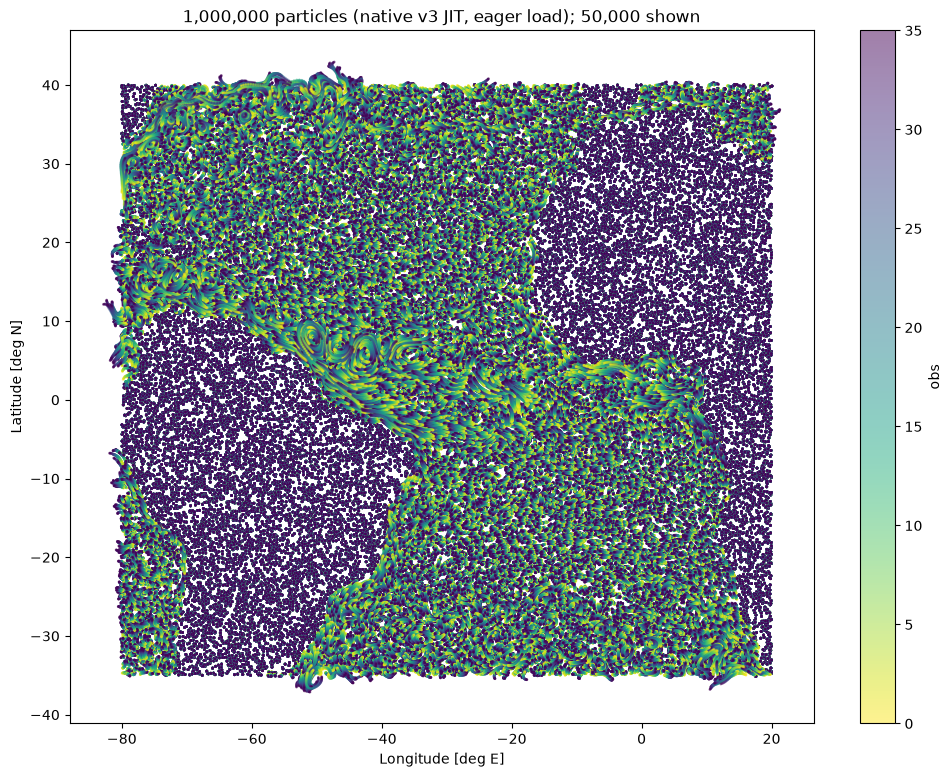

In [10]:
n_traj = traj.sizes["trajectory"]
n_plot = min(50_000, n_traj)
plot_ids = rng.choice(n_traj, size=n_plot, replace=False)
mask = np.isin(np.arange(n_traj), plot_ids)

sub = traj.isel(trajectory=mask)
lon_p = sub["lon"].values
lat_p = sub["lat"].values
obs_p = np.broadcast_to(np.arange(sub.sizes["obs"]), lon_p.shape)

fig, ax = plt.subplots(figsize=(12, 9))
scatter = ax.scatter(
    lon_p.reshape(-1),
    lat_p.reshape(-1),
    c=obs_p.reshape(-1),
    s=1,
    alpha=0.5,
    cmap="viridis_r",
)
ax.set_xlabel("Longitude [deg E]")
ax.set_ylabel("Latitude [deg N]")
ax.set_title(f"{n_particles:,} particles (native v3 JIT, eager load); {n_plot:,} shown")
fig.colorbar(scatter, ax=ax, label="obs")
plt.show()